## Clustering and Initialization

In [1]:
import sys
import os

sys.path.append(os.path.abspath("script"))

In [2]:
from synthetic_data import generate_blobs
from plots import plot_synthetic_points, plot_kmeans_result, results_kmeans_kmeanspp, plot_iterations, plot_strip, plot_best_worst_comparison
from kmeans import Kmeans, KmeansPlusPlus

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import load_digits, fetch_openml

#### Synthetic Datasets 

Dataset with good clustering and $100$ points for each cluster.

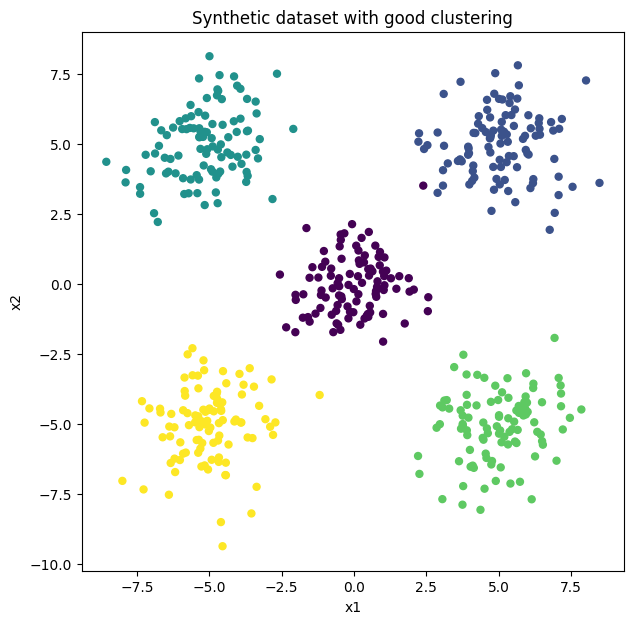

In [ ]:
centers = [
    (0.0, 0.0),
    (5.0, 5.0),
    (-5.0, 5.0),
    (5.0, -5.0),
    (-5.0, -5.0)
]

cluster_sizes = [100, 100, 100, 100, 100]

n_samples = 500     # total number of points 
std = 1.2           # deviation standard
n_features = 2      # number of features
random_state = 42   # random seed

X, y = generate_blobs(centers=centers, 
                      cluster_sizes=cluster_sizes, 
                      std=std, 
                      n_features=n_features, 
                      random_state=random_state)

plot_synthetic_points(X, y)

Dataset with overlapped clusters and $100$ points for each cluster 

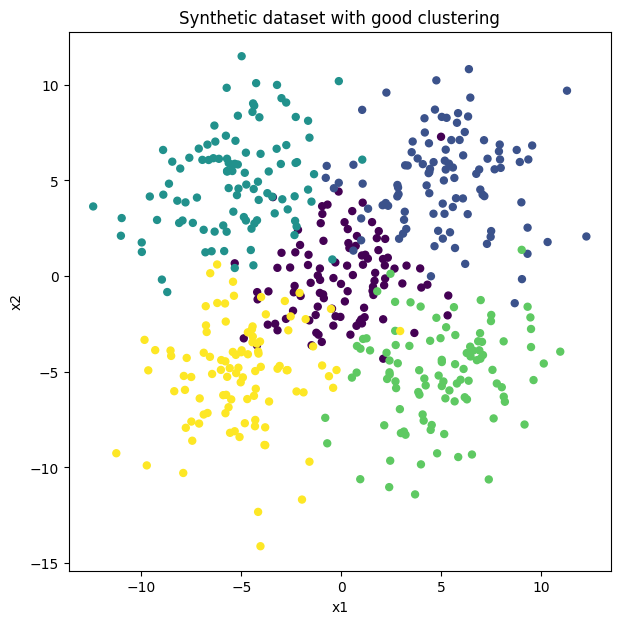

In [4]:
centers_overlap = [
    (0.0, 0.0),
    (3.0, 3.0),
    (-3.0, 3.0),
    (3.0, -3.0),
    (-3.0, -3.0)
]

cluster_sizes = [100, 100, 100, 100, 100]

n_samples = 500
std = 2.5
n_features = 2
random_state = 42

X_overlap, y_overlap = generate_blobs(centers=centers, 
                      cluster_sizes=cluster_sizes, 
                      std=std, 
                      n_features=n_features, 
                      random_state=random_state)

plot_synthetic_points(X_overlap, y_overlap)

Dataset with good clustering and different number of points for each cluster.

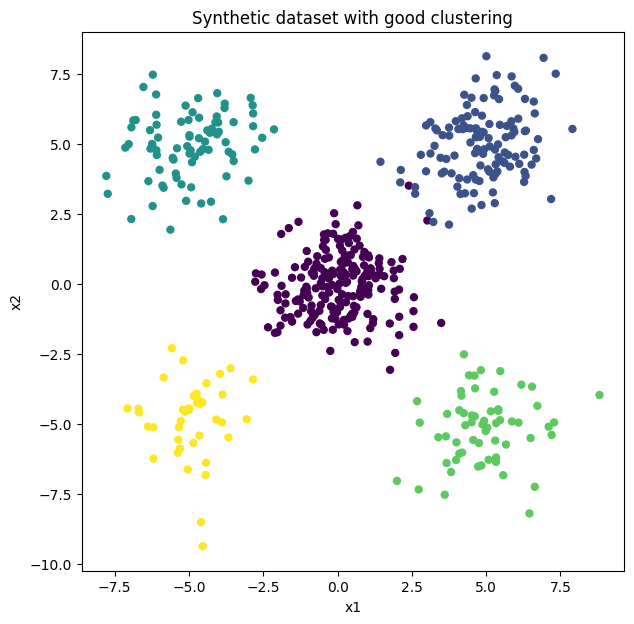

In [5]:
centers_imbalanced = [
    (0.0, 0.0),
    (5.0, 5.0),
    (-5.0, 5.0),
    (5.0, -5.0),
    (-5.0, -5.0)
]

cluster_sizes = [200, 120, 80, 60, 40]
std = 1.2
n_features = 2
random_state = 42

X_imbalanced, y_imbalanced = generate_blobs(centers=centers, 
                      cluster_sizes=cluster_sizes, 
                      std=std, 
                      n_features=n_features, 
                      random_state=random_state)

plot_synthetic_points(X_imbalanced, y_imbalanced)

Dataset with overlapped clusters and different number of points for each cluster.

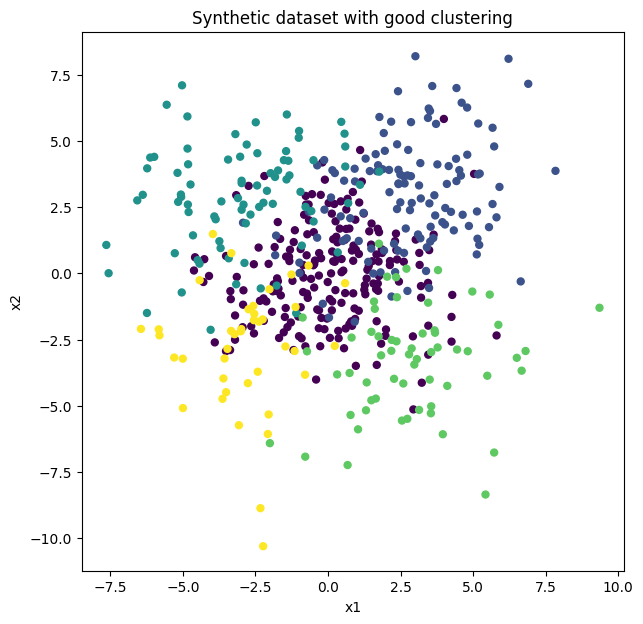

In [6]:
centers_hard = [
    (0.0, 0.0),
    (3.0, 3.0),
    (-3.0, 3.0),
    (3.0, -3.0),
    (-3.0, -3.0)
]

cluster_sizes_hard = [200, 120, 80, 60, 40]
std = 2
n_features = 2
random_state = 42

X_hard, y_hard = generate_blobs(
    centers=centers_hard,
    cluster_sizes=cluster_sizes_hard,
    std=std,
    n_features=n_features,
    random_state=random_state
)

plot_synthetic_points(X_hard, y_hard)

#### Real-world datasets

The MNIST dataset is a widely used benchmark in machine learning, consisting of 70000 grayscale images of handwritten digits (0–9), each represented as a 784-dimensional vector obtained by flattening 28 $\times$ 28 pixel images. 

From original dataset, i take a subset of 3000 examples, due to computational matters.

In [20]:
X_mnist, y_mnist = fetch_openml(
    "mnist_784",
    version=1,
    return_X_y=True,
    as_frame=False
)

subset_size = 3000
random_state_mnist = 42

X_mnist = X_mnist.astype(np.float64) / 255.0
y_mnist = y_mnist.astype(int)

rng = np.random.default_rng(random_state_mnist)
idx = rng.choice(X_mnist.shape[0], size=subset_size, replace=False)

X_mnist = X_mnist[idx]
y_mnist = y_mnist[idx]

print("Shape X_MNIST =", X_mnist.shape)
print("Shape y_MNIST =", y_mnist.shape)

df_mnist = pd.DataFrame(X_mnist)
df_mnist["label"] = y_mnist

df_mnist

Shape X_MNIST = (3000, 784)
Shape y_MNIST = (3000,)


,0,1,2,3,4,5,6,7,8,9,...,775,776,777,778,779,780,781,782,783,label
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2
2996,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3
2997,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2
2998,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7


In [21]:
df_mnist['label'].value_counts()

label
7    330
1    317
0    317
3    317
4    312
8    301
9    286
2    286
5    267
6    267
Name: count, dtype: int64

#### Run K-Means and K-means++

Multiple runs of Kmeans and Kmeans++ on synthetic dataset (mine).

In [10]:
# settings
n_clusters = 5
n_runs = 100
max_iter = 100
tol = 1e-4

inertias_kmeans = []
n_iters_kmeans = []
labels_kmeans = []
centroids_kmeans = [] 

inertias_kmeanspp = []
n_iters_kmeanspp = []
labels_kmeanspp = []
centroids_kmeanspp = []

for seed in range(n_runs):
    # kmeans
    model_kmeans = Kmeans(
        n_clusters=n_clusters,
        max_iter=max_iter,
        tol=tol,
        random_state=seed
    )

    model_kmeans.fit(X)

    inertias_kmeans.append(model_kmeans.inertia)
    n_iters_kmeans.append(model_kmeans.n_iter)
    labels_kmeans.append(model_kmeans.labels.copy())
    centroids_kmeans.append(model_kmeans.centroids.copy())

    # kmeans++
    model_kmeanspp = KmeansPlusPlus(
        n_clusters=n_clusters,
        max_iter=max_iter,
        tol=tol,
        random_state=seed
    )

    model_kmeanspp.fit(X)

    inertias_kmeanspp.append(model_kmeanspp.inertia)
    n_iters_kmeanspp.append(model_kmeanspp.n_iter)
    labels_kmeanspp.append(model_kmeanspp.labels.copy())
    centroids_kmeanspp.append(model_kmeanspp.centroids.copy())

inertias_kmeans = np.array(inertias_kmeans)
n_iters_kmeans = np.array(n_iters_kmeans)

inertias_kmeanspp = np.array(inertias_kmeanspp)
n_iters_kmeanspp = np.array(n_iters_kmeanspp)

Multiple runs of Kmeans and Kmeans++ on MNIST dataset.

In [23]:
# settings
n_clusters = 10
n_runs = 50
max_iter = 100
tol = 1e-4

inertias_kmeans_mnist = []
n_iters_kmeans_mnist = []
labels_kmeans_mnist = []
centroids_kmeans_mnist = [] 

inertias_kmeanspp_mnist = []
n_iters_kmeanspp_mnist = []
labels_kmeanspp_mnist = []
centroids_kmeanspp_mnist = []

for seed in range(n_runs):
    # kmeans
    model_kmeans_mnist = Kmeans(
        n_clusters=n_clusters,
        max_iter=max_iter,
        tol=tol,
        random_state=seed
    )

    model_kmeans_mnist.fit(X_mnist)

    inertias_kmeans_mnist.append(model_kmeans_mnist.inertia)
    n_iters_kmeans_mnist.append(model_kmeans_mnist.n_iter)
    labels_kmeans_mnist.append(model_kmeans_mnist.labels.copy())
    centroids_kmeans_mnist.append(model_kmeans_mnist.centroids.copy())

    # kmeans++
    model_kmeanspp_mnist = KmeansPlusPlus(
        n_clusters=n_clusters,
        max_iter=max_iter,
        tol=tol,
        random_state=seed
    )

    model_kmeanspp_mnist.fit(X_mnist)

    inertias_kmeanspp_mnist.append(model_kmeanspp_mnist.inertia)
    n_iters_kmeanspp_mnist.append(model_kmeanspp_mnist.n_iter)
    labels_kmeanspp_mnist.append(model_kmeanspp_mnist.labels.copy())
    centroids_kmeanspp_mnist.append(model_kmeanspp_mnist.centroids.copy())

inertias_kmeans_mnist = np.array(inertias_kmeans_mnist)
n_iters_kmeans_mnist = np.array(n_iters_kmeans_mnist)

inertias_kmeanspp_mnist = np.array(inertias_kmeanspp_mnist)
n_iters_kmeanspp_mnist = np.array(n_iters_kmeanspp_mnist)

#### Results K-Means and K-means++ on synthetic dataset (mine)

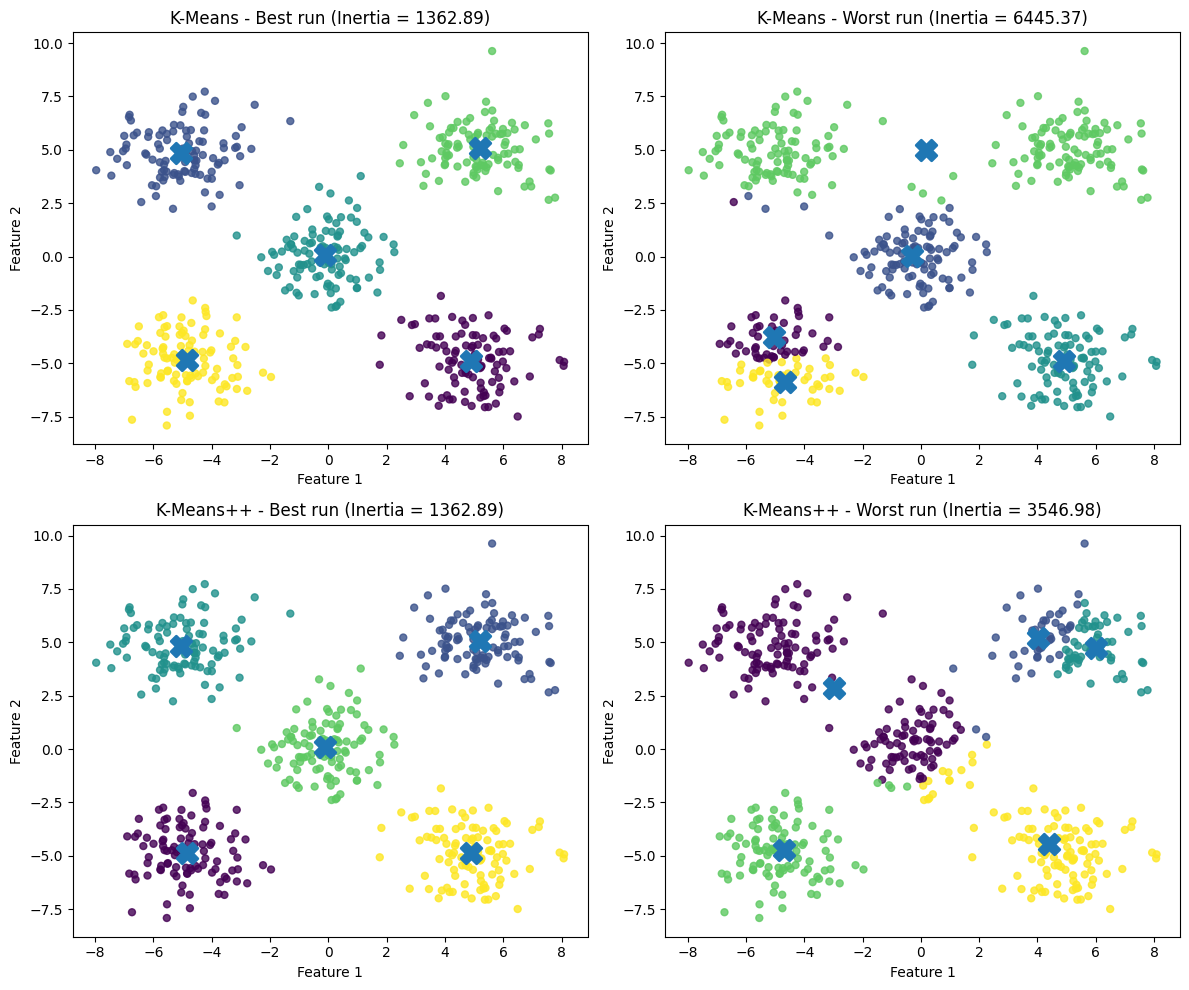

In [24]:
plot_best_worst_comparison(
    X,
    inertias_kmeans,
    labels_kmeans,
    centroids_kmeans,
    inertias_kmeanspp,
    labels_kmeanspp,
    centroids_kmeanspp
)

In [25]:
results_kmeans_kmeanspp(X,
                        inertias_kmeans,
                        n_iters_kmeans,
                        inertias_kmeanspp,
                        n_iters_kmeanspp)


K-Means
--------
Mean inertia    : 1650.1833
Std inertia     : 1095.6251
Min inertia     : 1362.8852
Max inertia     : 6445.3705
Mean iterations : 8.68

K-Means++
-----------
Mean inertia    : 1384.7262
Std inertia     : 217.3151
Min inertia     : 1362.8852
Max inertia     : 3546.9838
Mean iterations : 4.61


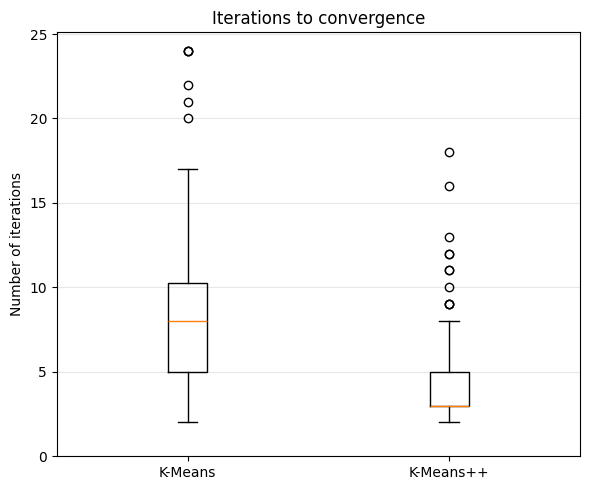

In [26]:
plot_iterations(n_iters_kmeans, n_iters_kmeanspp)

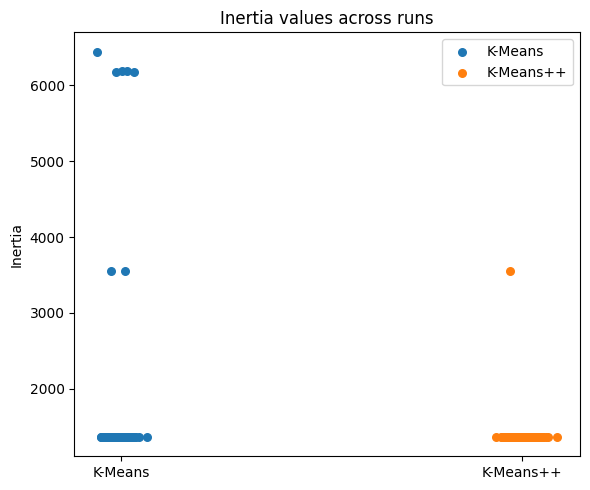

In [27]:
plot_strip(inertias_kmeans, inertias_kmeanspp)

#### Results K-Means and K-means++ on MNIST dataset    

In [28]:
results_kmeans_kmeanspp(X,
                        inertias_kmeans_mnist,
                        n_iters_kmeans_mnist,
                        inertias_kmeanspp_mnist,
                        n_iters_kmeanspp_mnist)


K-Means
--------
Mean inertia    : 118535.0055
Std inertia     : 286.2635
Min inertia     : 118009.9615
Max inertia     : 119242.8549
Mean iterations : 40.18

K-Means++
-----------
Mean inertia    : 118629.7647
Std inertia     : 365.6151
Min inertia     : 118006.7044
Max inertia     : 119696.0676
Mean iterations : 34.14


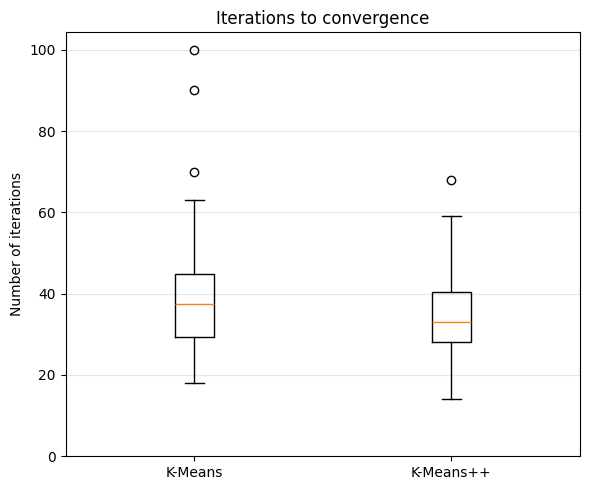

In [29]:
plot_iterations(n_iters_kmeans_mnist, n_iters_kmeanspp_mnist)

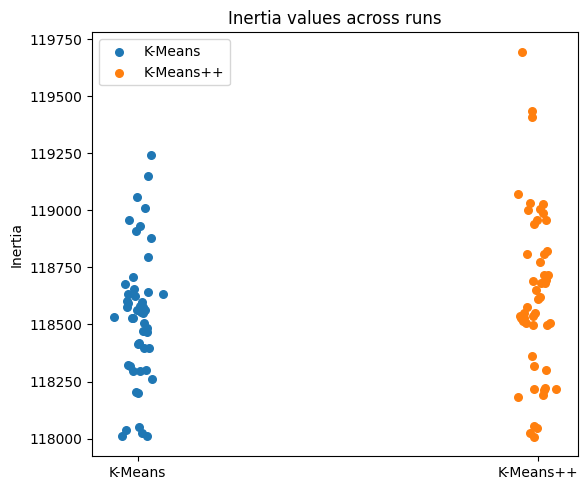

In [30]:
plot_strip(inertias_kmeans_mnist, inertias_kmeanspp_mnist)

#### Comparison with KMeans from scikit-learn library

In [26]:
# multiple runs of KMeans from scikit learn on digits dataset
inertias_sklearn = []
n_iters_sklearn = []
labels_sklearn = []
centroids_sklearn = []

inertias_sklearn_pp = []
n_iters_sklearn_pp = []
labels_sklearn_pp = []
centroids_sklearn_pp = []

# settings
n_clusters = 5
n_runs = 100
max_iter = 100
tol = 1e-4

for seed in range(n_runs):
    model_sklearn = KMeans(
        n_clusters=n_clusters,
        init="random",
        n_init=1,
        max_iter=max_iter,
        tol=tol,
        random_state=seed
    )

    model_sklearn.fit(X)

    inertias_sklearn.append(model_sklearn.inertia_)
    n_iters_sklearn.append(model_sklearn.n_iter_)
    labels_sklearn.append(model_sklearn.labels_.copy())
    centroids_sklearn.append(model_sklearn.cluster_centers_.copy())

    model_sklearn_pp = KMeans(
        n_clusters=n_clusters,
        init='k-means++',
        n_init=1,
        max_iter=max_iter,
        tol=tol,
        random_state=seed
    )

    model_sklearn_pp.fit(X)

    inertias_sklearn_pp.append(model_sklearn_pp.inertia_)
    n_iters_sklearn_pp.append(model_sklearn_pp.n_iter_)
    labels_sklearn_pp.append(model_sklearn_pp.labels_.copy())
    centroids_sklearn_pp.append(model_sklearn_pp.cluster_centers_.copy())

inertias_sklearn = np.array(inertias_sklearn)
n_iters_sklearn = np.array(n_iters_sklearn)

inertias_sklearn_pp = np.array(inertias_sklearn_pp)
n_iters_sklearn_pp = np.array(n_iters_sklearn_pp)

print("\nScikit-learn K-Means")
print("--------------------")
print(f"Mean inertia    : {np.mean(inertias_sklearn):.4f}")
print(f"Std inertia     : {np.std(inertias_sklearn):.4f}")
print(f"Min inertia     : {np.min(inertias_sklearn):.4f}")
print(f"Max inertia     : {np.max(inertias_sklearn):.4f}")
print(f"Mean iterations : {np.mean(n_iters_sklearn):.2f}")

print("\nScikit-learn K-Means++")
print("--------------------")
print(f"Mean inertia    : {np.mean(inertias_sklearn_pp):.4f}")
print(f"Std inertia     : {np.std(inertias_sklearn_pp):.4f}")
print(f"Min inertia     : {np.min(inertias_sklearn_pp):.4f}")
print(f"Max inertia     : {np.max(inertias_sklearn_pp):.4f}")
print(f"Mean iterations : {np.mean(n_iters_sklearn_pp):.2f}")


Scikit-learn K-Means
--------------------
Mean inertia    : 1665.9726
Std inertia     : 1129.0012
Min inertia     : 1362.8852
Max inertia     : 6182.0555
Mean iterations : 8.23

Scikit-learn K-Means++
--------------------
Mean inertia    : 1362.8852
Std inertia     : 0.0000
Min inertia     : 1362.8852
Max inertia     : 1362.8852
Mean iterations : 3.02


In [33]:
# settings
n_clusters = 10
n_runs = 50
max_iter = 100
tol = 1e-4

inertias_sklearn_mnist = []
n_iters_sklearn_mnist = []
labels_sklearn_mnist = []
centroids_sklearn_mnist = []

inertias_sklearn_pp_mnist = []
n_iters_sklearn_pp_mnist = []
labels_sklearn_pp_mnist = []
centroids_sklearn_pp_mnist = []

for seed in range(n_runs):
    model_sklearn_mnist = KMeans(
        n_clusters=n_clusters,
        init="random",
        n_init=1,
        max_iter=max_iter,
        tol=tol,
        random_state=seed
    )

    model_sklearn_mnist.fit(X_mnist)

    inertias_sklearn_mnist.append(model_sklearn_mnist.inertia_)
    n_iters_sklearn_mnist.append(model_sklearn_mnist.n_iter_)
    labels_sklearn_mnist.append(model_sklearn_mnist.labels_.copy())
    centroids_sklearn_mnist.append(model_sklearn_mnist.cluster_centers_.copy())

    model_sklearn_pp_mnist = KMeans(
        n_clusters=n_clusters,
        init='k-means++',
        n_init=1,
        max_iter=max_iter,
        tol=tol,
        random_state=seed
    )

    model_sklearn_pp_mnist.fit(X_mnist)

    inertias_sklearn_pp_mnist.append(model_sklearn_pp_mnist.inertia_)
    n_iters_sklearn_pp_mnist.append(model_sklearn_pp_mnist.n_iter_)
    labels_sklearn_pp_mnist.append(model_sklearn_pp_mnist.labels_.copy())
    centroids_sklearn_pp_mnist.append(model_sklearn_pp_mnist.cluster_centers_.copy())

inertias_sklearn_mnist = np.array(inertias_sklearn_mnist)
n_iters_sklearn_mnist = np.array(n_iters_sklearn_mnist)

inertias_sklearn_pp_mnist = np.array(inertias_sklearn_pp_mnist)
n_iters_sklearn_pp_mnist = np.array(n_iters_sklearn_pp_mnist)

print("\nScikit-learn K-Means")
print("--------------------")
print(f"Mean inertia    : {np.mean(inertias_sklearn_mnist):.4f}")
print(f"Std inertia     : {np.std(inertias_sklearn_mnist):.4f}")
print(f"Min inertia     : {np.min(inertias_sklearn_mnist):.4f}")
print(f"Max inertia     : {np.max(inertias_sklearn_mnist):.4f}")
print(f"Mean iterations : {np.mean(n_iters_sklearn_mnist):.2f}")

print("\nScikit-learn K-Means++")
print("--------------------")
print(f"Mean inertia    : {np.mean(inertias_sklearn_pp_mnist):.4f}")
print(f"Std inertia     : {np.std(inertias_sklearn_pp_mnist):.4f}")
print(f"Min inertia     : {np.min(inertias_sklearn_pp_mnist):.4f}")
print(f"Max inertia     : {np.max(inertias_sklearn_pp_mnist):.4f}")
print(f"Mean iterations : {np.mean(n_iters_sklearn_pp_mnist):.2f}")

print("\n\nRandom min:", np.min(inertias_sklearn_mnist))
print("Random max:", np.max(inertias_sklearn_mnist))

print("KMeans++ min:", np.min(inertias_sklearn_pp_mnist))
print("KMeans++ max:", np.max(inertias_sklearn_pp_mnist))


Scikit-learn K-Means
--------------------
Mean inertia    : 118572.0478
Std inertia     : 348.6141
Min inertia     : 118033.7921
Max inertia     : 119685.7386
Mean iterations : 33.22

Scikit-learn K-Means++
--------------------
Mean inertia    : 118665.6247
Std inertia     : 390.2786
Min inertia     : 118029.2893
Max inertia     : 119544.4475
Mean iterations : 37.66


Random min: 118033.7920587148
Random max: 119685.73864420722
KMeans++ min: 118029.28925240166
KMeans++ max: 119544.44747505132


#### Overlapping clusters